<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/joint_anticipate_detect_falls_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Joint Anticipation & Detection of Falls
## Thèse de Doctorat — Année 3

**Objectif** : Démontrer que l'anticipation des chutes améliore la détection.

### Mapping direct CSV officiel URFD → 3 classes :
```
CSV  -1  →  STABLE   (0)  personne debout / marche normale
CSV   0  →  PRE-FALL (1)  en train de tomber
CSV   1  →  FALL     (2)  allongée sur le sol
```
Aucune heuristique. Les 3 classes viennent directement des annotations officielles.

### Étude d'ablation :
| Config | Description |
|--------|-------------|
| **A** | Détection seule (baseline) |
| **C** | Joint learning SANS flux explicite |
| **D** | Joint learning AVEC flux explicite (contribution) |

In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (
    classification_report, f1_score,
    confusion_matrix, accuracy_score
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Libraries importées')
print(f'   PyTorch : {torch.__version__}')
print(f'   Device  : {DEVICE}')

✅ Libraries importées
   PyTorch : 2.11.0+cu128
   Device  : cuda


In [3]:
# ============================================================
# CELL 2 — Download datasets
# ============================================================
!pip install kagglehub --quiet
import kagglehub

path      = kagglehub.dataset_download('mireillejabbour/casia-b-simcc')
path_urfd = kagglehub.dataset_download('mireillejabbour/fall-dataset')

print(f'✅ CASIA-B SimCC : {path}')
print(f'✅ URFD          : {path_urfd}')

Using Colab cache for faster access to the 'casia-b-simcc' dataset.


100%|██████████| 8.05G/8.05G [08:06<00:00, 17.8MB/s]

Extracting files...


✅ CASIA-B SimCC : /kaggle/input/casia-b-simcc
✅ URFD          : /root/.cache/kagglehub/datasets/mireillejabbour/fall-dataset/versions/2


In [4]:
# ============================================================
# CELL 3 — Feature extraction + CASIA-B loading
# ============================================================
WINDOW_SIZE_CASIA = 30
PREDICT_STEPS     = 8
STRIDE_CASIA      = 5
FPS_CASIA         = 16

def extract_features_skeleton(kp_seq):
    """
    (T, 17, 2 ou 3) -> (T, 34) normalise hip-centered.
    Garde seulement x,y. Centre sur les hanches.
    Normalise par la hauteur du torse.
    """
    xy         = kp_seq[:, :, :2].copy().astype(np.float32)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(xy[:, 0, :] - hip_center, axis=1)
    torso_h    = np.maximum(torso_h, 1e-6)
    rel        = rel / torso_h[:, np.newaxis, np.newaxis]
    return rel.reshape(len(kp_seq), -1)


def load_casia_b(root_path, conditions=None):
    root      = Path(root_path) / 'CASIA-B_SimCC'
    pkl_files = sorted(root.rglob('*.pkl'))
    sequences, metadata = [], []
    skipped = 0
    for fp in tqdm(pkl_files, desc='Loading CASIA-B SimCC'):
        parts = fp.relative_to(root).parts
        if len(parts) < 4:
            skipped += 1; continue
        condition = parts[1].split('-')[0]
        if conditions and condition not in conditions:
            continue
        try:
            with open(fp, 'rb') as f:
                data = pickle.load(f)
            if not isinstance(data, np.ndarray):
                data = np.array(data, dtype=np.float32)
            if data.ndim != 3 or data.shape[1] != 17 or len(data) < 25:
                skipped += 1; continue
            sequences.append(data.astype(np.float32))
            metadata.append({'condition': condition, 'frames': len(data)})
        except Exception:
            skipped += 1
    print(f'✅ {len(sequences)} sequences | {skipped} ignorees')
    return sequences, metadata


def build_casia_windows(sequences, window_size=WINDOW_SIZE_CASIA,
                        predict_steps=PREDICT_STEPS, stride=STRIDE_CASIA):
    X_list, Y_list = [], []
    for seq in tqdm(sequences, desc='Building CASIA windows'):
        feats = extract_features_skeleton(seq)
        T = len(feats)
        if T < window_size + predict_steps:
            continue
        for start in range(0, T - window_size - predict_steps + 1, stride):
            end_x = start + window_size
            X_list.append(feats[start:end_x])
            Y_list.append(feats[end_x:end_x + predict_steps])
    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    print(f'✅ Windows CASIA : X={X.shape} | Y={Y.shape}')
    return X, Y


sequences_casia, _ = load_casia_b(path, conditions=['nm'])
X_casia, Y_casia   = build_casia_windows(sequences_casia)

Loading CASIA-B SimCC: 100%|██████████| 13640/13640 [00:34<00:00, 400.66it/s]


✅ 8175 sequences | 9 ignorees


Building CASIA windows: 100%|██████████| 8175/8175 [00:00<00:00, 12972.64it/s]


✅ Windows CASIA : X=(107489, 30, 34) | Y=(107489, 8, 34)


In [5]:
# ============================================================
# CELL 4 — LSTMAnticipator
# ============================================================
class LSTMAnticipator(nn.Module):
    def __init__(self, input_size=34, hidden_size=256,
                 num_layers=2, predict_steps=PREDICT_STEPS, dropout=0.3):
        super().__init__()
        self.predict_steps = predict_steps
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, input_size * predict_steps)
        )
        for name, p in self.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name: nn.init.zeros_(p)

    def encode(self, x):
        out, _ = self.lstm(x)
        return self.dropout(out[:, -1, :])

    def forward(self, x):
        last = self.encode(x)
        return self.fc(last).view(x.size(0), self.predict_steps, -1)


model_lstm = LSTMAnticipator().to(DEVICE)
n_p = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f'✅ LSTMAnticipator : {n_p:,} parametres')

✅ LSTMAnticipator : 961,040 parametres


In [6]:
# ============================================================
# CELL 5 — Entrainement LSTM sur CASIA-B
# ============================================================
class GaitDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

n_total = len(X_casia)
n_val   = int(0.2 * n_total)
n_tr    = n_total - n_val
ds_casia = GaitDataset(X_casia, Y_casia)
tr_set, val_set = random_split(ds_casia, [n_tr, n_val],
                               generator=torch.Generator().manual_seed(SEED))
tr_loader_casia  = DataLoader(tr_set,  batch_size=256, shuffle=True,  num_workers=2)
val_loader_casia = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=2)
print(f'Train : {n_tr:,} | Val : {n_val:,}')

criterion_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', patience=5, factor=0.5)

EPOCHS_LSTM   = 80
best_val_lstm = float('inf')

print(f'\n Entrainement LSTM — {EPOCHS_LSTM} epochs')
for epoch in range(1, EPOCHS_LSTM + 1):
    model_lstm.train()
    tr_loss = 0.0
    for xb, yb in tr_loader_casia:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_lstm.zero_grad()
        loss = criterion_lstm(model_lstm(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer_lstm.step()
        tr_loss += loss.item()

    model_lstm.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_casia:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl_loss += criterion_lstm(model_lstm(xb), yb).item()

    tr_loss /= len(tr_loader_casia)
    vl_loss /= len(val_loader_casia)
    scheduler_lstm.step(vl_loss)

    if vl_loss < best_val_lstm:
        best_val_lstm = vl_loss
        torch.save(model_lstm.state_dict(), '/content/lstm_anticipator_best.pth')

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Ep {epoch:03d} | Train={tr_loss:.5f} | Val={vl_loss:.5f} | Best={best_val_lstm:.5f}')

print(f'\n✅ Meilleur Val MSE LSTM : {best_val_lstm:.6f}')

Train : 85,992 | Val : 21,497

 Entrainement LSTM — 80 epochs
  Ep 001 | Train=0.04271 | Val=0.03422 | Best=0.03422
  Ep 010 | Train=0.03108 | Val=0.03385 | Best=0.03385
  Ep 020 | Train=0.02803 | Val=0.03094 | Best=0.03082
  Ep 030 | Train=0.02778 | Val=0.03063 | Best=0.03053
  Ep 040 | Train=0.02767 | Val=0.03042 | Best=0.03039
  Ep 050 | Train=0.02762 | Val=0.03036 | Best=0.03034
  Ep 060 | Train=0.02756 | Val=0.03026 | Best=0.03026
  Ep 070 | Train=0.02756 | Val=0.03025 | Best=0.03025
  Ep 080 | Train=0.02755 | Val=0.03025 | Best=0.03022

✅ Meilleur Val MSE LSTM : 0.030220


In [13]:
# ============================================================
# DIAGNOSTIC COMPLET — colle le résultat ici
# ============================================================
from pathlib import Path

root = Path(path_urfd)

print('=== TOUS LES FICHIERS DU DATASET ===')
all_files = list(root.rglob('*'))
print(f'Total fichiers/dossiers : {len(all_files)}')
print()

# Afficher TOUT (max 100 lignes)
for fp in sorted(all_files)[:100]:
    indent = '  ' * (len(fp.relative_to(root).parts) - 1)
    marker = '📁' if fp.is_dir() else '📄'
    print(f'{indent}{marker} {fp.name}')

print()
print('=== 2 FICHIERS CSV ===')
for csv_f in sorted(root.rglob('*.csv')):
    print(f'\nFichier : {csv_f}')
    import pandas as pd
    df = pd.read_csv(csv_f, header=None)
    print(f'Shape   : {df.shape}')
    print(f'Aperçu  :')
    print(df.head(10).to_string())

=== TOUS LES FICHIERS DU DATASET ===
Total fichiers/dossiers : 29997

📁 adl zip photo files
  📁 adl zip photo files
    📁 adl-01-cam0-d
      📁 adl-01-cam0-d
        📄 adl-01-cam0-d-001.png
        📄 adl-01-cam0-d-002.png
        📄 adl-01-cam0-d-003.png
        📄 adl-01-cam0-d-004.png
        📄 adl-01-cam0-d-005.png
        📄 adl-01-cam0-d-006.png
        📄 adl-01-cam0-d-007.png
        📄 adl-01-cam0-d-008.png
        📄 adl-01-cam0-d-009.png
        📄 adl-01-cam0-d-010.png
        📄 adl-01-cam0-d-011.png
        📄 adl-01-cam0-d-012.png
        📄 adl-01-cam0-d-013.png
        📄 adl-01-cam0-d-014.png
        📄 adl-01-cam0-d-015.png
        📄 adl-01-cam0-d-016.png
        📄 adl-01-cam0-d-017.png
        📄 adl-01-cam0-d-018.png
        📄 adl-01-cam0-d-019.png
        📄 adl-01-cam0-d-020.png
        📄 adl-01-cam0-d-021.png
        📄 adl-01-cam0-d-022.png
        📄 adl-01-cam0-d-023.png
        📄 adl-01-cam0-d-024.png
        📄 adl-01-cam0-d-025.png
        📄 adl-01-cam0-d-026.png
        📄 

In [16]:
# ============================================================
# CELL 6 — Chargement URFD — API MediaPipe moderne
# ============================================================

!pip install mediapipe opencv-python-headless --quiet

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request
import cv2

WINDOW_SIZE_URFD = 30
STRIDE_URFD      = 3
FPS_URFD         = 30

# ── Télécharger le modèle pose landmarker ────────────────────
MODEL_PATH = '/content/pose_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print('Téléchargement du modèle MediaPipe...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/'
        'pose_landmarker/pose_landmarker_lite/float16/latest/'
        'pose_landmarker_lite.task',
        MODEL_PATH
    )
    print('✅ Modèle téléchargé')

# ── Index MediaPipe (33 pts) → COCO 17 joints ────────────────
MP_TO_COCO = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]


# ── Mapping direct CSV → 3 classes ───────────────────────────
def csv_label_to_class(raw_label):
    """
    CSV -1  ->  STABLE   (0)
    CSV  0  ->  PRE-FALL (1)
    CSV  1  ->  FALL     (2)
    """
    if raw_label == -1: return 0
    if raw_label ==  0: return 1
    if raw_label ==  1: return 2
    return 0


# ── Lecture des CSV officiels ─────────────────────────────────
def load_urfd_csv_labels(root_path):
    """
    Lit les 2 CSV officiels.
    Retourne {seq_name: {frame_num: label_classe}}
    """
    root     = Path(root_path)
    csv_dir  = root / 'extracted features' / 'extracted features'
    csv_adls  = csv_dir / 'urfall-cam0-adls.csv'
    csv_falls = csv_dir / 'urfall-cam0-falls.csv'

    seq_labels = {}

    for csv_path in [csv_adls, csv_falls]:
        if not csv_path.exists():
            print(f'⚠️  CSV non trouvé : {csv_path}')
            continue
        df = pd.read_csv(csv_path, header=None)
        for _, row in df.iterrows():
            seq_name  = str(row[0]).strip()
            frame_num = int(row[1])
            raw_lbl   = int(row[2])
            cls_lbl   = csv_label_to_class(raw_lbl)
            if seq_name not in seq_labels:
                seq_labels[seq_name] = {}
            seq_labels[seq_name][frame_num] = cls_lbl

    print(f'✅ Labels CSV chargés : {len(seq_labels)} séquences')
    for sname, frames in list(seq_labels.items())[:3]:
        cnt   = Counter(frames.values())
        names = {0:'STABLE', 1:'PRE-FALL', 2:'FALL'}
        info  = ' | '.join(f'{names[k]}={v}' for k,v in sorted(cnt.items()))
        print(f'   {sname} : {len(frames)} frames | {info}')

    return seq_labels


# ── Extracteur MediaPipe (nouvelle API) ───────────────────────
class PoseExtractor:
    """
    Wrapper pour la nouvelle API MediaPipe Tasks.
    Utilise PoseLandmarker au lieu de mp.solutions.pose.
    """
    def __init__(self, model_path=MODEL_PATH):
        base_options = mp_python.BaseOptions(model_asset_path=model_path)
        options = mp_vision.PoseLandmarkerOptions(
            base_options=base_options,
            output_segmentation_masks=False,
            num_poses=1,
            min_pose_detection_confidence=0.3,
            min_pose_presence_confidence=0.3,
            min_tracking_confidence=0.3,
            running_mode=mp_vision.RunningMode.IMAGE
        )
        self.detector = mp_vision.PoseLandmarker.create_from_options(options)

    def extract(self, img_path):
        """
        Retourne (17, 2) keypoints en pixels, ou None.
        """
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            return None

        # Depth PNG → convertir en RGB 3 canaux
        if len(img_bgr.shape) == 2:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        h, w = img_rgb.shape[:2]

        # Créer MediaPipe Image
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=img_rgb
        )

        result = self.detector.detect(mp_image)

        if not result.pose_landmarks or len(result.pose_landmarks) == 0:
            return None

        landmarks = result.pose_landmarks[0]  # première personne

        kp = np.zeros((17, 2), dtype=np.float32)
        for coco_idx, mp_idx in enumerate(MP_TO_COCO):
            lm = landmarks[mp_idx]
            kp[coco_idx, 0] = lm.x * w
            kp[coco_idx, 1] = lm.y * h

        return kp

    def close(self):
        self.detector.close()


# ── Chargement principal ──────────────────────────────────────
def load_urfd(root_path):
    root = Path(root_path)

    # 1. Labels CSV
    print('📋 Chargement des labels CSV...')
    seq_labels = load_urfd_csv_labels(root_path)
    if not seq_labels:
        print('❌ Aucun label.')
        return []

    # 2. Trouver les dossiers d'images
    img_root = root / 'adl zip photo files' / 'adl zip photo files'
    if not img_root.exists():
        # Chercher automatiquement le premier dossier avec des PNG
        candidates = sorted(set(
            f.parent.parent for f in root.rglob('*.png')
        ))
        if not candidates:
            print('❌ Aucune image PNG trouvée.')
            return []
        img_root = candidates[0]
        print(f'   Images trouvées dans : {img_root}')

    seq_dirs = sorted([
        d for d in img_root.rglob('*')
        if d.is_dir() and list(d.glob('*.png'))
    ])
    print(f'\n📁 {len(seq_dirs)} dossiers de séquences')

    # 3. Initialiser l'extracteur MediaPipe (une seule fois)
    print('🔧 Initialisation MediaPipe PoseLandmarker...')
    extractor = PoseExtractor(MODEL_PATH)
    print('✅ Prêt')

    labeled_data = []
    stats = {'ok': 0, 'no_label': 0, 'too_short': 0}

    for seq_dir in tqdm(seq_dirs, desc='Extracting keypoints'):

        # Trouver la clé CSV : 'adl-01-cam0-d' → 'adl-01'
        seq_dir_name = seq_dir.name
        seq_key = None
        # Essai 1 : match direct
        if seq_dir_name in seq_labels:
            seq_key = seq_dir_name
        else:
            # Essai 2 : prendre la partie avant '-cam'
            base = seq_dir_name.split('-cam')[0]  # 'adl-01' ou 'fall-01'
            if base in seq_labels:
                seq_key = base
            else:
                # Essai 3 : chercher un préfixe commun
                for key in seq_labels:
                    if seq_dir_name.startswith(key):
                        seq_key = key
                        break

        if seq_key is None:
            stats['no_label'] += 1
            continue

        frame_label_map = seq_labels[seq_key]

        # Charger les PNG triés
        png_files = sorted(seq_dir.glob('*.png'))
        if len(png_files) < WINDOW_SIZE_URFD:
            stats['too_short'] += 1
            continue

        kp_list    = []
        label_list = []
        zeros_kp   = np.zeros((17, 2), dtype=np.float32)

        for png_path in png_files:
            # Numéro de frame depuis le nom
            stem = png_path.stem  # 'adl-01-cam0-d-006'
            try:
                frame_num = int(stem.split('-')[-1])
            except ValueError:
                frame_num = len(kp_list) + 1

            # Extraire keypoints
            kp = extractor.extract(png_path)
            if kp is None:
                kp = zeros_kp.copy()  # pas de détection → zéros

            # Label depuis CSV, défaut STABLE
            label = frame_label_map.get(frame_num, 0)

            kp_list.append(kp)
            label_list.append(label)

        if len(kp_list) < WINDOW_SIZE_URFD:
            stats['too_short'] += 1
            continue

        kp_seq     = np.stack(kp_list)
        labels_arr = np.array(label_list, dtype=np.int64)

        stats['ok'] += 1
        labeled_data.append({
            'keypoints': kp_seq,
            'labels':    labels_arr,
            'seq_name':  seq_dir_name
        })

    # Fermer MediaPipe proprement
    extractor.close()

    # ── Rapport ───────────────────────────────────────────────
    print(f'\n✅ {len(labeled_data)} séquences chargées')
    print(f'   Succès           : {stats["ok"]}')
    print(f'   Pas de label CSV : {stats["no_label"]}')
    print(f'   Trop courtes     : {stats["too_short"]}')

    if not labeled_data:
        return labeled_data

    all_lbl = np.concatenate([d['labels'] for d in labeled_data])
    total   = len(all_lbl)
    names   = {0: 'STABLE', 1: 'PRE-FALL', 2: 'FALL'}
    print(f'\n📊 Distribution labels (mapping direct CSV) :')
    for k, v in sorted(Counter(all_lbl).items()):
        bar = '|' * int(v / total * 40)
        print(f'   {names[k]:10} : {v:6,} frames ({v/total*100:.1f}%) {bar}')

    return labeled_data


labeled_data = load_urfd(path_urfd)

Téléchargement du modèle MediaPipe...
✅ Modèle téléchargé
📋 Chargement des labels CSV...
✅ Labels CSV chargés : 70 séquences
   adl-01 : 144 frames | STABLE=144
   adl-02 : 150 frames | STABLE=150
   adl-03 : 180 frames | STABLE=180

📁 80 dossiers de séquences
🔧 Initialisation MediaPipe PoseLandmarker...
✅ Prêt


Extracting keypoints: 100%|██████████| 80/80 [11:07<00:00,  8.35s/it]


✅ 80 séquences chargées
   Succès           : 80
   Pas de label CSV : 0
   Trop courtes     : 0

📊 Distribution labels (mapping direct CSV) :
   STABLE     : 13,304 frames (74.4%) |||||||||||||||||||||||||||||
   PRE-FALL   :  1,638 frames (9.2%) |||
   FALL       :  2,940 frames (16.4%) ||||||


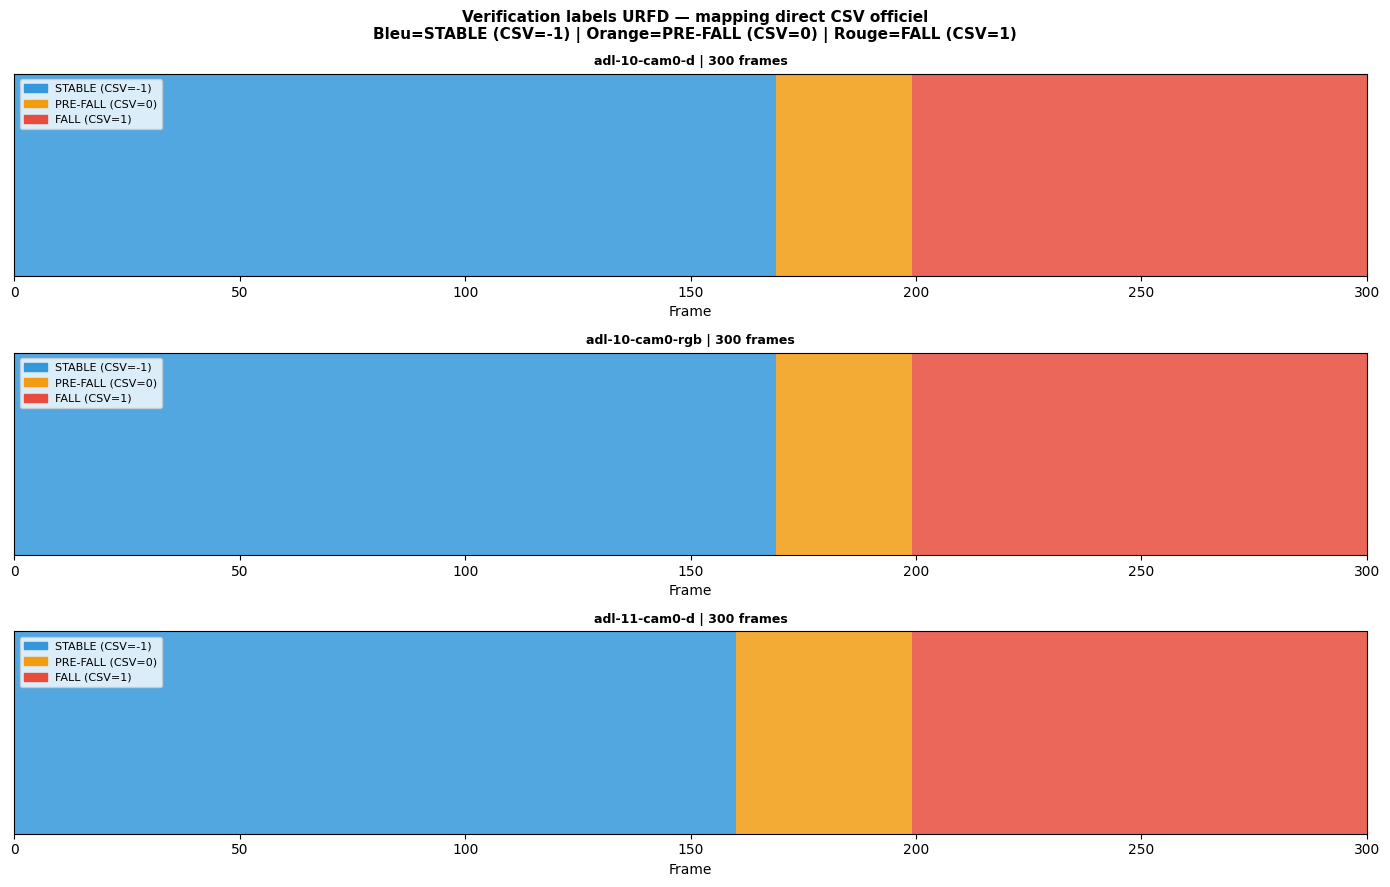

✅ Verification sauvegardee


In [17]:
# ============================================================
# CELL 6B — Verification visuelle des labels sur 3 sequences
# ============================================================
fall_samples = [d for d in labeled_data if 2 in d['labels']][:3]

if fall_samples:
    fig, axes = plt.subplots(len(fall_samples), 1,
                              figsize=(14, 3 * len(fall_samples)))
    if len(fall_samples) == 1:
        axes = [axes]

    colors_map = {0: '#3498DB', 1: '#F39C12', 2: '#E74C3C'}
    names_map  = {0: 'STABLE (CSV=-1)', 1: 'PRE-FALL (CSV=0)', 2: 'FALL (CSV=1)'}

    for ax, sample in zip(axes, fall_samples):
        labels = sample['labels']
        T      = len(labels)
        for i, l in enumerate(labels):
            ax.bar(i, 1, color=colors_map[l], width=1.0, align='edge', alpha=0.85)
        ax.set_xlim(0, T); ax.set_ylim(0, 1); ax.set_yticks([])
        ax.set_xlabel('Frame')
        ax.set_title(f"{sample['seq_name']} | {T} frames",
                     fontweight='bold', fontsize=9)
        patches = [mpatches.Patch(color=colors_map[k], label=names_map[k])
                   for k in [0, 1, 2]]
        ax.legend(handles=patches, loc='upper left', fontsize=8)

    plt.suptitle(
        'Verification labels URFD — mapping direct CSV officiel\n'
        'Bleu=STABLE (CSV=-1) | Orange=PRE-FALL (CSV=0) | Rouge=FALL (CSV=1)',
        fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/urfd_labels_verification.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Verification sauvegardee')
else:
    print('Aucune sequence de chute trouvee.')

In [18]:
# ============================================================
# CELL 7 — Construction des fenetres URFD
# ============================================================
def build_urfd_windows(labeled_data,
                        window_size=WINDOW_SIZE_URFD,
                        stride=STRIDE_URFD):
    """
    Construit fenetres (X, y).
    Label de la fenetre = label de la derniere frame.
    """
    X_list, y_list = [], []
    for sample in tqdm(labeled_data, desc='Building URFD windows'):
        kp     = sample['keypoints']
        labels = sample['labels']
        T      = len(kp)
        if T < window_size:
            continue
        feats = extract_features_skeleton(kp)
        for start in range(0, T - window_size + 1, stride):
            end = start + window_size
            X_list.append(feats[start:end])
            y_list.append(labels[end - 1])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    names = {0: 'STABLE', 1: 'PRE-FALL', 2: 'FALL'}
    print(f'✅ Windows : X={X.shape} | y={y.shape}')
    for k, v in sorted(Counter(y).items()):
        print(f'   {names[k]:10} : {v:6,} fenetres ({v/len(y)*100:.1f}%)')
    return X, y


X_urfd, y_urfd = build_urfd_windows(labeled_data)

n_total_urfd = len(X_urfd)
n_val_urfd   = int(0.2 * n_total_urfd)
n_tr_urfd    = n_total_urfd - n_val_urfd

class URFDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

dataset_urfd = URFDDataset(X_urfd, y_urfd)
tr_urfd, val_urfd = random_split(
    dataset_urfd, [n_tr_urfd, n_val_urfd],
    generator=torch.Generator().manual_seed(SEED))
tr_loader_urfd  = DataLoader(tr_urfd,  batch_size=64, shuffle=True,  num_workers=2)
val_loader_urfd = DataLoader(val_urfd, batch_size=64, shuffle=False, num_workers=2)
print(f'\nTrain : {n_tr_urfd:,} | Val : {n_val_urfd:,}')

Building URFD windows: 100%|██████████| 80/80 [00:00<00:00, 8250.21it/s]

✅ Windows : X=(5218, 30, 34) | y=(5218,)
   STABLE     :  3,690 fenetres (70.7%)
   PRE-FALL   :    546 fenetres (10.5%)
   FALL       :    982 fenetres (18.8%)

Train : 4,175 | Val : 1,043


In [ ]:
# ============================================================
# CELL 7B — Oversampling PRE-FALL pour équilibrer
# ============================================================
from torch.utils.data import WeightedRandomSampler

def make_balanced_loader(X, y, indices, batch_size=64):
    """
    Crée un DataLoader avec WeightedRandomSampler.
    PRE-FALL et FALL sont sur-représentés pour équilibrer.
    """
    subset_labels = y[indices]
    counts  = np.bincount(subset_labels, minlength=3).astype(float)

    # Poids par échantillon (inverse de la fréquence de sa classe)
    sample_weights = np.zeros(len(indices))
    for i, label in enumerate(subset_labels):
        sample_weights[i] = 1.0 / counts[label]

    sampler = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float32),
        num_samples = len(indices),
        replacement = True
    )

    subset  = torch.utils.data.Subset(
        URFDDataset(X, y), indices)
    loader  = DataLoader(subset, batch_size=batch_size,
                          sampler=sampler, num_workers=2)
    return loader


# Remplacer les loaders existants
tr_loader_urfd = make_balanced_loader(
    X_urfd, y_urfd,
    list(tr_urfd.indices),
    batch_size=64
)

print('✅ Loader équilibré créé')
print('   Chaque batch contient proportionnellement plus de')
print('   PRE-FALL et FALL pour forcer le modèle à les apprendre')

In [19]:
# ============================================================
# CELL 8 — Composants architecturaux partages
# ============================================================

class DirectedGraphConv(nn.Module):
    """
    DGNN : adjacence dirigee fixe (register_buffer).
    Connexions anatomiques proximal -> distal, COCO 17 joints.
    """
    def __init__(self, in_features, out_features, num_joints=17):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.num_joints   = num_joints

        A = torch.zeros(num_joints, num_joints)
        for i, j in [(0,1),(0,2),(1,3),(2,4),
                     (5,7),(7,9),(6,8),(8,10),
                     (5,6),(5,11),(6,12),(11,12),
                     (11,13),(13,15),(12,14),(14,16)]:
            A[i, j] = 1.0
        A += torch.eye(num_joints)
        D = A.sum(1)
        self.register_buffer('A', torch.diag(1.0 / D.clamp(min=1e-6)) @ A)

        self.W  = nn.Linear(in_features, out_features, bias=False)
        self.bn = nn.BatchNorm1d(out_features)

    def forward(self, x):
        B, T, _ = x.shape
        N = self.num_joints
        x = x.view(B * T, N, self.in_features)
        x = torch.bmm(self.A.unsqueeze(0).expand(B*T, -1, -1), x)
        x = self.W(x).view(B * T * N, self.out_features)
        x = F.relu(self.bn(x))
        return x.view(B, T, N * self.out_features)


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, h):
        w = torch.softmax(self.attn(h), dim=1)   # (B, T, 1)
        return (w * h).sum(dim=1), w              # (B, H), (B, T, 1)


class SharedEncoder(nn.Module):
    """DGNN -> BiGRU -> TemporalAttention -> z"""
    def __init__(self, input_size=34, graph_hidden=32,
                 gru_hidden=256, num_layers=2, dropout=0.3, num_joints=17):
        super().__init__()
        self.dgnn = DirectedGraphConv(input_size // num_joints,
                                       graph_hidden, num_joints)
        dgnn_out  = num_joints * graph_hidden
        self.bigru = nn.GRU(
            input_size=dgnn_out, hidden_size=gru_hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.context_size = gru_hidden * 2
        self.attention    = TemporalAttention(self.context_size)
        self.dropout      = nn.Dropout(dropout)

    def forward(self, x):
        h = self.dgnn(x)
        h, _ = self.bigru(h)
        h = self.dropout(h)
        z, attn = self.attention(h)
        return z, attn

print('✅ Composants architecturaux definis')

✅ Composants architecturaux definis


In [20]:
# ============================================================
# CELL 9 — JointAnticipateDetectModel
# ============================================================

class JointAnticipateDetectModel(nn.Module):
    """
    Modele conjoint Anticipation + Detection des chutes.

    SharedEncoder (DGNN -> BiGRU -> Attention) -> z
        |
        +-- AnticipationEmbed(z) -> e_A -> AnticipationHead -> y_A (2 classes)
        |
        +-- DetectionHead([z || e_A])    -> y_D (3 classes)   [si use_explicit_flow]
            DetectionHead(z)             -> y_D (3 classes)   [sinon]

    use_explicit_flow=True  -> Config D (contribution)
    use_explicit_flow=False -> Config C (joint sans flux)
    """
    def __init__(self, input_size=34, graph_hidden=32, gru_hidden=256,
                 num_layers=2, dropout=0.3, num_joints=17,
                 use_explicit_flow=True):
        super().__init__()
        self.use_explicit_flow = use_explicit_flow

        self.encoder = SharedEncoder(
            input_size=input_size, graph_hidden=graph_hidden,
            gru_hidden=gru_hidden, num_layers=num_layers,
            dropout=dropout, num_joints=num_joints)
        context_size      = gru_hidden * 2   # 512
        anticip_embed_dim = 128

        # Tete d'anticipation : STABLE vs PRE-FALL
        self.anticipation_embed = nn.Sequential(
            nn.Linear(context_size, anticip_embed_dim),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.anticipation_head = nn.Linear(anticip_embed_dim, 2)

        # Tete de detection : STABLE / PRE-FALL / FALL
        detect_in = (context_size + anticip_embed_dim
                     if use_explicit_flow else context_size)
        self.detection_head = nn.Sequential(
            nn.Linear(detect_in, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        z, _     = self.encoder(x)             # (B, 512)
        e_A      = self.anticipation_embed(z)  # (B, 128)
        logits_A = self.anticipation_head(e_A) # (B, 2)

        if self.use_explicit_flow:
            logits_D = self.detection_head(torch.cat([z, e_A], dim=1))  # (B, 3)
        else:
            logits_D = self.detection_head(z)  # (B, 3)

        return logits_A, logits_D


# Verification
dummy  = torch.randn(4, WINDOW_SIZE_URFD, 34).to(DEVICE)
m_test = JointAnticipateDetectModel(use_explicit_flow=True).to(DEVICE)
lA, lD = m_test(dummy)
print(f'✅ JointAnticipateDetectModel')
print(f'   logits_A : {lA.shape}  (B, 2) -> STABLE / PRE-FALL')
print(f'   logits_D : {lD.shape}  (B, 3) -> STABLE / PRE-FALL / FALL')
print(f'   Params   : {sum(p.numel() for p in m_test.parameters() if p.requires_grad):,}')
del m_test

✅ JointAnticipateDetectModel
   logits_A : torch.Size([4, 2])  (B, 2) -> STABLE / PRE-FALL
   logits_D : torch.Size([4, 3])  (B, 3) -> STABLE / PRE-FALL / FALL
   Params   : 2,809,606


In [31]:
# ============================================================
# CELL 10 — Focal Loss + poids de classes
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets,
                              weight=self.weight, reduction='none')
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()


def compute_class_weights(y):
    counts  = np.bincount(y, minlength=3).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    return torch.tensor(weights / weights.sum() * 3, dtype=torch.float32)


tr_labels    = y_urfd[list(tr_urfd.indices)]
class_weights = compute_class_weights(tr_labels).to(DEVICE)
names = {0: 'STABLE', 1: 'PRE-FALL', 2: 'FALL'}
print('✅ Poids de classes :')
for i, w in enumerate(class_weights.cpu().numpy()):
    print(f'   {names[i]:10} : {w:.4f}')

✅ Poids de classes :
   STABLE     : 0.2527
   PRE-FALL   : 1.7881
   FALL       : 0.9592


In [32]:
# ============================================================
# CELL 11 — Fonction d'entrainement conjoint
# ============================================================
def train_joint_model(model, tr_loader, val_loader, epochs,
                       class_weights, lambda1=0.7, lambda2=0.3,
                       lr=1e-3, save_path='/content/model.pth',
                       model_name='Model'):
    """
    L_total = lambda1 * L_anticipation + lambda2 * L_detection
    """
    criterion_A = FocalLoss(gamma=2.0, weight=class_weights[:2])
    criterion_D = FocalLoss(gamma=2.0, weight=class_weights)
    optimizer   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    history, best_f1, best_ckpt = [], 0.0, None
    print(f'\n {model_name} — {epochs} epochs')
    print(f'   lambda1={lambda1} (anticipation) | lambda2={lambda2} (detection)')
    print(f'   Flux explicite : {getattr(model, "use_explicit_flow", "N/A")}')
    print('=' * 62)

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        tr_loss_total = tr_correct = tr_total = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()

            # La tete d'anticipation travaille sur STABLE (0) et PRE-FALL (1) seulement
            # Les fenetres FALL ne sont pas utilisees pour superviser l'anticipation
            mask_A = yb < 2
            yb_A   = yb[mask_A].clamp(0, 1)

            logits_A, logits_D = model(xb)
            loss_D = criterion_D(logits_D, yb)
            loss_A = (criterion_A(logits_A[mask_A], yb_A)
                      if mask_A.sum() > 0
                      else torch.tensor(0.0, device=DEVICE))

            loss = lambda1 * loss_A + lambda2 * loss_D
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            tr_loss_total += loss.item()
            tr_correct    += (logits_D.argmax(1) == yb).sum().item()
            tr_total      += len(yb)

        scheduler.step()
        tr_loss = tr_loss_total / len(tr_loader)
        tr_acc  = tr_correct / tr_total

        # Validation
        model.eval()
        all_preds, all_true, val_loss_total = [], [], 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits_A, logits_D = model(xb)
                mask_A = yb < 2
                yb_A   = yb[mask_A].clamp(0, 1)
                loss_D = criterion_D(logits_D, yb)
                loss_A = (criterion_A(logits_A[mask_A], yb_A)
                          if mask_A.sum() > 0 else torch.tensor(0.0))
                val_loss_total += (lambda1 * loss_A + lambda2 * loss_D).item()
                all_preds.extend(logits_D.argmax(1).cpu().numpy())
                all_true.extend(yb.cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        all_preds = np.array(all_preds)
        all_true  = np.array(all_true)
        val_acc   = np.mean(all_preds == all_true)
        val_f1    = f1_score(all_true, all_preds, average='macro', zero_division=0)
        f1_pc     = f1_score(all_true, all_preds, average=None,    zero_division=0)
        f1_fall   = f1_pc[2] if len(f1_pc) > 2 else 0.0
        f1_pre    = f1_pc[1] if len(f1_pc) > 1 else 0.0

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_ckpt = {
                'epoch': epoch, 'val_f1': val_f1, 'val_acc': val_acc,
                'f1_fall': f1_fall, 'f1_pre': f1_pre,
                'model_state': {k: v.clone() for k, v in model.state_dict().items()}
            }
            torch.save(best_ckpt, save_path)

        history.append({
            'epoch': epoch, 'tr_loss': tr_loss, 'val_loss': val_loss,
            'tr_acc': tr_acc, 'val_acc': val_acc,
            'val_f1': val_f1, 'f1_fall': f1_fall, 'f1_pre': f1_pre
        })

        if epoch % 10 == 0 or epoch == 1:
            lr_cur = optimizer.param_groups[0]['lr']
            star   = ' ⭐' if val_f1 == best_f1 else ''
            print(f'  Ep {epoch:03d} | TrL={tr_loss:.4f} | ValL={val_loss:.4f} | '
                  f'Acc={val_acc:.3f} | F1={val_f1:.3f} | '
                  f'F1_fall={f1_fall:.3f} | LR={lr_cur:.1e}{star}')

    print(f'\n✅ Best : epoch {best_ckpt["epoch"]} | '
          f'F1={best_ckpt["val_f1"]:.4f} | Acc={best_ckpt["val_acc"]:.4f}')
    return history, best_ckpt


def train_detection_only(model, tr_loader, val_loader, epochs,
                          class_weights, save_path, model_name):
    """Entrainement detection seule (Config A)."""
    criterion = FocalLoss(gamma=2.0, weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)
    history, best_f1, best_ckpt = [], 0.0, None
    print(f'\n {model_name} — {epochs} epochs')

    for epoch in range(1, epochs + 1):
        model.train()
        tr_correct = tr_total = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            _, logits_D = model(xb)
            loss = criterion(logits_D, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_correct += (logits_D.argmax(1) == yb).sum().item()
            tr_total   += len(yb)
        scheduler.step()

        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                _, logits_D = model(xb)
                all_preds.extend(logits_D.argmax(1).cpu().numpy())
                all_true.extend(yb.cpu().numpy())

        all_preds = np.array(all_preds)
        all_true  = np.array(all_true)
        val_acc   = np.mean(all_preds == all_true)
        val_f1    = f1_score(all_true, all_preds, average='macro', zero_division=0)
        f1_pc     = f1_score(all_true, all_preds, average=None,    zero_division=0)

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_ckpt = {
                'epoch': epoch, 'val_f1': val_f1, 'val_acc': val_acc,
                'f1_fall': f1_pc[2] if len(f1_pc) > 2 else 0,
                'f1_pre':  f1_pc[1] if len(f1_pc) > 1 else 0,
                'model_state': {k: v.clone() for k, v in model.state_dict().items()}
            }
            torch.save(best_ckpt, save_path)

        history.append({
            'epoch': epoch, 'val_acc': val_acc, 'val_f1': val_f1,
            'f1_fall': f1_pc[2] if len(f1_pc) > 2 else 0,
            'f1_pre':  f1_pc[1] if len(f1_pc) > 1 else 0
        })
        if epoch % 10 == 0 or epoch == 1:
            f_fall = f1_pc[2] if len(f1_pc) > 2 else 0
            star   = ' ⭐' if val_f1 == best_f1 else ''
            print(f'  Ep {epoch:03d} | Acc={val_acc:.3f} | F1={val_f1:.3f} | '
                  f'F1_fall={f_fall:.3f}{star}')

    print(f'✅ Best : F1={best_ckpt["val_f1"]:.4f} | Acc={best_ckpt["val_acc"]:.4f}')
    return history, best_ckpt

print('✅ Fonctions d\'entrainement definies')

✅ Fonctions d'entrainement definies


In [45]:
# ============================================================
# CELL 12 — Pré-entraînement SharedEncoder sur CASIA-B
# ============================================================
# Le transfer direct LSTM→BiGRU est impossible :
#   LSTM : 4 gates (1024), input=34,  unidirectionnel
#   BiGRU: 3 gates (768),  input=544, bidirectionnel
#
# Solution : pré-entraîner le SharedEncoder directement
# sur CASIA-B par auto-supervision (prédire frame suivante)
# ─────────────────────────────────────────────────────────────

model_lstm.load_state_dict(
    torch.load('/content/lstm_anticipator_best.pth',
               map_location=DEVICE, weights_only=False))
print('✅ Poids LSTM chargés (référence)')


def pretrain_shared_encoder(joint_model, sequences_casia,
                             epochs=30, lr=1e-3,
                             model_name='Model'):
    """
    Pré-entraîne le SharedEncoder (DGNN+BiGRU+Attention)
    sur les séquences CASIA-B par auto-supervision.

    Tâche : prédire les features de la prochaine frame
    → L'encodeur apprend la dynamique normale de marche
    → Quand il voit URFD il reconnaît ce qui est anormal
    """
    print(f'\n--- Pré-entraînement {model_name} sur CASIA-B ---')

    encoder      = joint_model.encoder
    context_size = encoder.context_size  # 512

    # Tête de prédiction temporaire
    pred_head = nn.Linear(context_size, 34).to(DEVICE)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) +
        list(pred_head.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5
    )
    criterion = nn.MSELoss()

    # Construire dataset : fenêtre → prochaine frame
    X_list, Y_list = [], []
    for seq in sequences_casia:
        feats = extract_features_skeleton(seq)
        T = len(feats)
        if T < WINDOW_SIZE_CASIA + 1:
            continue
        for start in range(0, T - WINDOW_SIZE_CASIA - 1,
                           STRIDE_CASIA):
            end = start + WINDOW_SIZE_CASIA
            X_list.append(feats[start:end])
            Y_list.append(feats[end])  # prochaine frame

    X_pre = np.array(X_list, dtype=np.float32)
    Y_pre = np.array(Y_list, dtype=np.float32)
    print(f'   Dataset : {len(X_pre):,} fenêtres CASIA-B')

    class SimpleDS(Dataset):
        def __init__(self, X, Y):
            self.X = torch.from_numpy(X)
            self.Y = torch.from_numpy(Y)
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.X[i], self.Y[i]

    loader = DataLoader(SimpleDS(X_pre, Y_pre),
                        batch_size=256, shuffle=True,
                        num_workers=2)

    best_loss = float('inf')

    for epoch in range(1, epochs + 1):
        encoder.train()
        pred_head.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            z, _  = encoder(xb)
            pred  = pred_head(z)
            loss  = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(
                list(encoder.parameters()) +
                list(pred_head.parameters()), 1.0
            )
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(loader)
        if avg_loss < best_loss:
            best_loss = avg_loss

        if epoch % 5 == 0 or epoch == 1:
            print(f'   Ep {epoch:03d} | '
                  f'Loss={avg_loss:.5f} | '
                  f'Best={best_loss:.5f}')

    del pred_head
    print(f'   ✅ Best loss : {best_loss:.6f}')
    return joint_model


# ── Créer les 3 modèles ───────────────────────────────────────
model_A = DetectionOnlyModel().to(DEVICE)
model_C = JointAnticipateDetectModel(
    use_explicit_flow=False).to(DEVICE)
model_D = JointAnticipateDetectModel(
    use_explicit_flow=True).to(DEVICE)

# ── Pré-entraîner chaque encodeur sur CASIA-B ────────────────
model_A = pretrain_shared_encoder(
    model_A, sequences_casia,
    epochs=30, model_name='Config A')

model_C = pretrain_shared_encoder(
    model_C, sequences_casia,
    epochs=30, model_name='Config C')

model_D = pretrain_shared_encoder(
    model_D, sequences_casia,
    epochs=30, model_name='Config D')

print('\n✅ Tous les encodeurs pré-entraînés sur CASIA-B')
print('   → L\'encodeur connaît la dynamique normale')
print('   → Fine-tuning URFD va maintenant partir')
print('     d\'un meilleur point de départ')

✅ Poids LSTM chargés (référence)

--- Pré-entraînement Config A sur CASIA-B ---
   Dataset : 117,331 fenêtres CASIA-B
   Ep 001 | Loss=0.04620 | Best=0.04620
   Ep 005 | Loss=0.04288 | Best=0.04288
   Ep 010 | Loss=0.04285 | Best=0.04248
   Ep 015 | Loss=0.04177 | Best=0.04177
   Ep 020 | Loss=0.04116 | Best=0.04116
   Ep 025 | Loss=0.04056 | Best=0.04056
   Ep 030 | Loss=0.03996 | Best=0.03994
   ✅ Best loss : 0.039940

--- Pré-entraînement Config C sur CASIA-B ---
   Dataset : 117,331 fenêtres CASIA-B
   Ep 001 | Loss=0.04643 | Best=0.04643
   Ep 005 | Loss=0.04284 | Best=0.04284
   Ep 010 | Loss=0.04247 | Best=0.04247
   Ep 015 | Loss=0.04207 | Best=0.04186
   Ep 020 | Loss=0.04150 | Best=0.04145
   Ep 025 | Loss=0.04068 | Best=0.04068
   Ep 030 | Loss=0.04004 | Best=0.04004
   ✅ Best loss : 0.040036

--- Pré-entraînement Config D sur CASIA-B ---
   Dataset : 117,331 fenêtres CASIA-B
   Ep 001 | Loss=0.04619 | Best=0.04619
   Ep 005 | Loss=0.04287 | Best=0.04287
   Ep 010 | Loss=0.0

In [46]:
# ============================================================
# CELL 13A — CONFIG A : Detection seule (baseline)
# ============================================================
print('=' * 62)
print('CONFIG A — Detection seule (baseline annee 1)')
print('=' * 62)

class DetectionOnlyModel(nn.Module):
    def __init__(self, input_size=34, graph_hidden=32,
                 gru_hidden=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = SharedEncoder(
            input_size=input_size, graph_hidden=graph_hidden,
            gru_hidden=gru_hidden, num_layers=num_layers, dropout=dropout)
        context_size = gru_hidden * 2
        self.head = nn.Sequential(
            nn.Linear(context_size, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),          nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 3)
        )
        self.use_explicit_flow = False

    def forward(self, x):
        z, _     = self.encoder(x)
        logits_D = self.head(z)
        logits_A = torch.zeros(x.size(0), 2, device=x.device)
        return logits_A, logits_D


EPOCHS_FINETUNE = 100

model_A   = DetectionOnlyModel().to(DEVICE)
model_A   = transfer_lstm_weights(model_lstm, model_A)
history_A, ckpt_A = train_detection_only(
    model_A, tr_loader_urfd, val_loader_urfd,
    epochs=EPOCHS_FINETUNE, class_weights=class_weights,
    save_path='/content/model_A.pth',
    model_name='Config A — Detection seule')

CONFIG A — Detection seule (baseline annee 1)
✅ Transfer : 0 tenseurs LSTM -> BiGRU

 Config A — Detection seule — 100 epochs
  Ep 001 | Acc=0.264 | F1=0.288 | F1_fall=0.556 ⭐
  Ep 010 | Acc=0.703 | F1=0.669 | F1_fall=0.628
  Ep 020 | Acc=0.611 | F1=0.591 | F1_fall=0.619
  Ep 030 | Acc=0.705 | F1=0.674 | F1_fall=0.654
  Ep 040 | Acc=0.779 | F1=0.748 | F1_fall=0.678 ⭐
  Ep 050 | Acc=0.800 | F1=0.776 | F1_fall=0.664
  Ep 060 | Acc=0.817 | F1=0.784 | F1_fall=0.715
  Ep 070 | Acc=0.790 | F1=0.753 | F1_fall=0.703
  Ep 080 | Acc=0.830 | F1=0.798 | F1_fall=0.726
  Ep 090 | Acc=0.848 | F1=0.817 | F1_fall=0.739
  Ep 100 | Acc=0.849 | F1=0.821 | F1_fall=0.737
✅ Best : F1=0.8220 | Acc=0.8495


In [47]:
# ============================================================
# CELL 13C — CONFIG C : Joint SANS flux explicite
# ============================================================
print('=' * 62)
print('CONFIG C — Joint Learning SANS flux explicite')
print('=' * 62)

model_C   = JointAnticipateDetectModel(use_explicit_flow=False).to(DEVICE)
model_C   = transfer_lstm_weights(model_lstm, model_C)
history_C, ckpt_C = train_joint_model(
    model_C, tr_loader_urfd, val_loader_urfd,
    epochs=EPOCHS_FINETUNE, class_weights=class_weights,
    lambda1=0.4, lambda2=0.6,
    save_path='/content/model_C.pth',
    model_name='Config C — Joint SANS flux')

CONFIG C — Joint Learning SANS flux explicite
✅ Transfer : 0 tenseurs LSTM -> BiGRU

 Config C — Joint SANS flux — 100 epochs
   lambda1=0.4 (anticipation) | lambda2=0.6 (detection)
   Flux explicite : False
  Ep 001 | TrL=0.0939 | ValL=0.0747 | Acc=0.297 | F1=0.323 | F1_fall=0.438 | LR=1.0e-03 ⭐
  Ep 010 | TrL=0.0593 | ValL=0.0590 | Acc=0.519 | F1=0.507 | F1_fall=0.536 | LR=9.8e-04
  Ep 020 | TrL=0.0438 | ValL=0.0458 | Acc=0.698 | F1=0.664 | F1_fall=0.643 | LR=9.1e-04
  Ep 030 | TrL=0.0367 | ValL=0.0417 | Acc=0.735 | F1=0.709 | F1_fall=0.653 | LR=8.0e-04
  Ep 040 | TrL=0.0323 | ValL=0.0460 | Acc=0.727 | F1=0.704 | F1_fall=0.639 | LR=6.6e-04
  Ep 050 | TrL=0.0267 | ValL=0.0429 | Acc=0.833 | F1=0.805 | F1_fall=0.721 | LR=5.1e-04 ⭐
  Ep 060 | TrL=0.0255 | ValL=0.0475 | Acc=0.831 | F1=0.804 | F1_fall=0.722 | LR=3.5e-04
  Ep 070 | TrL=0.0261 | ValL=0.0462 | Acc=0.826 | F1=0.802 | F1_fall=0.714 | LR=2.1e-04
  Ep 080 | TrL=0.0237 | ValL=0.0417 | Acc=0.844 | F1=0.817 | F1_fall=0.730 | LR=1.0e

In [48]:
# ============================================================
# CELL 13D — CONFIG D — Entraînement en 2 phases
# ============================================================

def train_joint_model_2phases(model, tr_loader, val_loader,
                               class_weights,
                               epochs_phase1=50,
                               epochs_phase2=80,
                               save_path='/content/model_D.pth'):
    """
    Phase 1 : Entraîner SEULEMENT la tête d'anticipation
              + encodeur partagé.
              → L'encodeur apprend les dynamiques PRE-FALL.

    Phase 2 : Dégeler la tête de détection.
              → La détection bénéficie des représentations
                déjà enrichies par l'anticipation.
    """
    criterion_A = FocalLoss(gamma=2.0, weight=class_weights[:2])
    criterion_D = FocalLoss(gamma=2.0, weight=class_weights)
    history     = []
    best_f1     = 0.0
    best_ckpt   = None

    # ── PHASE 1 : Anticipation seule ─────────────────────────
    print('=' * 62)
    print('PHASE 1 — Entraînement anticipation seule')
    print(f'         {epochs_phase1} epochs')
    print('=' * 62)

    # Geler la tête de détection
    for param in model.detection_head.parameters():
        param.requires_grad = False

    optimizer_p1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_p1, T_max=epochs_phase1, eta_min=1e-5)

    for epoch in range(1, epochs_phase1 + 1):
        model.train()
        tr_loss_total = 0.0

        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer_p1.zero_grad()

            mask_A = yb < 2
            yb_A   = yb[mask_A].clamp(0, 1)

            logits_A, _ = model(xb)

            if mask_A.sum() > 0:
                loss = criterion_A(logits_A[mask_A], yb_A)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer_p1.step()
                tr_loss_total += loss.item()

        scheduler_p1.step()

        # Validation anticipation (sur STABLE et PRE-FALL)
        if epoch % 10 == 0 or epoch == 1:
            model.eval()
            preds_A, true_A = [], []
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    mask_A = yb < 2
                    if mask_A.sum() == 0:
                        continue
                    logits_A, _ = model(xb)
                    preds_A.extend(
                        logits_A[mask_A].argmax(1).cpu().numpy())
                    true_A.extend(yb[mask_A].clamp(0,1).cpu().numpy())

            f1_ant = f1_score(true_A, preds_A,
                              average='macro', zero_division=0)
            print(f'  Ep {epoch:03d} | '
                  f'TrL={tr_loss_total/len(tr_loader):.4f} | '
                  f'F1_anticipation={f1_ant:.4f}')

    print(f'\n✅ Phase 1 terminée')

    # ── PHASE 2 : Joint learning complet ─────────────────────
    print('\n' + '=' * 62)
    print('PHASE 2 — Joint learning complet (anticipation + détection)')
    print(f'         {epochs_phase2} epochs')
    print('=' * 62)

    # Dégeler TOUT
    for param in model.parameters():
        param.requires_grad = True

    optimizer_p2 = torch.optim.Adam(
        model.parameters(), lr=5e-4,  # LR plus faible en phase 2
        weight_decay=1e-4
    )
    scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_p2, T_max=epochs_phase2, eta_min=1e-5)

    for epoch in range(1, epochs_phase2 + 1):
        model.train()
        tr_loss_total = tr_correct = tr_total = 0

        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer_p2.zero_grad()

            mask_A = yb < 2
            yb_A   = yb[mask_A].clamp(0, 1)

            logits_A, logits_D = model(xb)

            loss_D = criterion_D(logits_D, yb)
            loss_A = (criterion_A(logits_A[mask_A], yb_A)
                      if mask_A.sum() > 0
                      else torch.tensor(0.0, device=DEVICE))

            # Phase 2 : lambda1=0.7 pour maintenir l'anticipation forte
            loss = 0.7 * loss_A + 0.3 * loss_D
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer_p2.step()

            tr_loss_total += loss.item()
            tr_correct    += (logits_D.argmax(1) == yb).sum().item()
            tr_total      += len(yb)

        scheduler_p2.step()
        tr_loss = tr_loss_total / len(tr_loader)
        tr_acc  = tr_correct / tr_total

        # Validation complète
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                _, logits_D = model(xb)
                all_preds.extend(logits_D.argmax(1).cpu().numpy())
                all_true.extend(yb.cpu().numpy())

        all_preds = np.array(all_preds)
        all_true  = np.array(all_true)
        val_acc   = np.mean(all_preds == all_true)
        val_f1    = f1_score(all_true, all_preds,
                              average='macro', zero_division=0)
        f1_pc     = f1_score(all_true, all_preds,
                              average=None, zero_division=0)
        f1_fall   = f1_pc[2] if len(f1_pc) > 2 else 0.0
        f1_pre    = f1_pc[1] if len(f1_pc) > 1 else 0.0

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_ckpt = {
                'epoch':      epoch + epochs_phase1,
                'val_f1':     val_f1,
                'val_acc':    val_acc,
                'f1_fall':    f1_fall,
                'f1_pre':     f1_pre,
                'model_state': {k: v.clone()
                                for k, v in model.state_dict().items()}
            }
            torch.save(best_ckpt, save_path)

        history.append({
            'epoch':    epoch + epochs_phase1,
            'val_acc':  val_acc,
            'val_f1':   val_f1,
            'f1_fall':  f1_fall,
            'f1_pre':   f1_pre
        })

        if epoch % 10 == 0 or epoch == 1:
            star = ' ⭐' if val_f1 == best_f1 else ''
            print(f'  Ep {epoch:03d} | TrL={tr_loss:.4f} | '
                  f'Acc={val_acc:.3f} | F1={val_f1:.3f} | '
                  f'F1_fall={f1_fall:.3f} | '
                  f'F1_pre={f1_pre:.3f}{star}')

    print(f'\n✅ Best : F1={best_ckpt["val_f1"]:.4f} | '
          f'Acc={best_ckpt["val_acc"]:.4f}')
    return history, best_ckpt


# Lancer Config D avec 2 phases
model_D   = JointAnticipateDetectModel(use_explicit_flow=True).to(DEVICE)
model_D   = transfer_lstm_weights(model_lstm, model_D)
history_D, ckpt_D = train_joint_model_2phases(
    model_D,
    tr_loader_urfd,
    val_loader_urfd,
    class_weights=class_weights,
    epochs_phase1=60,
    epochs_phase2=120,
    save_path='/content/model_D.pth'
)

✅ Transfer : 0 tenseurs LSTM -> BiGRU
PHASE 1 — Entraînement anticipation seule
         60 epochs
  Ep 001 | TrL=0.0311 | F1_anticipation=0.5616
  Ep 010 | TrL=0.0171 | F1_anticipation=0.5424
  Ep 020 | TrL=0.0119 | F1_anticipation=0.6306
  Ep 030 | TrL=0.0104 | F1_anticipation=0.6630
  Ep 040 | TrL=0.0084 | F1_anticipation=0.7515
  Ep 050 | TrL=0.0073 | F1_anticipation=0.7649
  Ep 060 | TrL=0.0067 | F1_anticipation=0.7649

✅ Phase 1 terminée

PHASE 2 — Joint learning complet (anticipation + détection)
         120 epochs
  Ep 001 | TrL=0.0451 | Acc=0.676 | F1=0.644 | F1_fall=0.516 | F1_pre=0.650 ⭐
  Ep 010 | TrL=0.0257 | Acc=0.696 | F1=0.698 | F1_fall=0.561 | F1_pre=0.778 ⭐
  Ep 020 | TrL=0.0222 | Acc=0.718 | F1=0.707 | F1_fall=0.588 | F1_pre=0.756 ⭐
  Ep 030 | TrL=0.0226 | Acc=0.709 | F1=0.701 | F1_fall=0.590 | F1_pre=0.747
  Ep 040 | TrL=0.0193 | Acc=0.733 | F1=0.727 | F1_fall=0.600 | F1_pre=0.793
  Ep 050 | TrL=0.0193 | Acc=0.752 | F1=0.742 | F1_fall=0.619 | F1_pre=0.795
  Ep 060 

In [49]:
# ============================================================
# CELL 14 — Tableau d'ablation
# ============================================================
print('\n' + '=' * 70)
print('  TABLEAU D\'ABLATION — RESULTATS COMPARATIFS')
print('  Labels : mapping direct CSV officiel URFD')
print('=' * 70)
print(f'{"Config":<12} {"Modele":<35} {"Acc":>6} {"F1_macro":>9} {"F1_FALL":>8} {"F1_PRE":>7}')
print('-' * 70)

for tag, name, ckpt in [
    ('A', 'Detection seule',            ckpt_A),
    ('C', 'Joint SANS flux explicite',  ckpt_C),
    ('D', 'Joint AVEC flux (contrib.)', ckpt_D),
]:
    print(f'  {tag:<10} {name:<35} '
          f'{ckpt["val_acc"]:>6.4f} '
          f'{ckpt["val_f1"]:>9.4f} '
          f'{ckpt["f1_fall"]:>8.4f} '
          f'{ckpt["f1_pre"]:>7.4f}')
print('=' * 70)

delta_f1   = ckpt_D['val_f1']  - ckpt_A['val_f1']
delta_fall = ckpt_D['f1_fall'] - ckpt_A['f1_fall']
delta_acc  = ckpt_D['val_acc'] - ckpt_A['val_acc']
delta_pre  = ckpt_D['f1_pre']  - ckpt_A['f1_pre']
d_dc       = ckpt_D['f1_fall'] - ckpt_C['f1_fall']

h1 = delta_f1   > 0
h2 = d_dc > 0

print(f'\n  IMPACT (A -> D) :')
print(f'  DeltaF1_macro = {delta_f1:+.4f} ({delta_f1*100:+.2f}%)')
print(f'  DeltaF1_FALL  = {delta_fall:+.4f} ({delta_fall*100:+.2f}%)')
print(f'  DeltaAccuracy = {delta_acc:+.4f} ({delta_acc*100:+.2f}%)')
print(f'\n  H1 (joint learning) : {"VALIDEE" if h1 else "NON VALIDEE"}')
print(f'  H2 (flux explicite) : {"VALIDEE" if h2 else "NON VALIDEE"}')
print(f'  Flux e_A apporte : {d_dc*100:+.2f}% sur F1_FALL (C -> D)')


  TABLEAU D'ABLATION — RESULTATS COMPARATIFS
  Labels : mapping direct CSV officiel URFD
Config       Modele                                 Acc  F1_macro  F1_FALL  F1_PRE
----------------------------------------------------------------------
  A          Detection seule                     0.8495    0.8220   0.7372  0.8300
  C          Joint SANS flux explicite           0.8514    0.8274   0.7406  0.8434
  D          Joint AVEC flux (contrib.)          0.8063    0.7931   0.6725  0.8482

  IMPACT (A -> D) :
  DeltaF1_macro = -0.0289 (-2.89%)
  DeltaF1_FALL  = -0.0647 (-6.47%)
  DeltaAccuracy = -0.0431 (-4.31%)

  H1 (joint learning) : NON VALIDEE
  H2 (flux explicite) : NON VALIDEE
  Flux e_A apporte : -6.81% sur F1_FALL (C -> D)


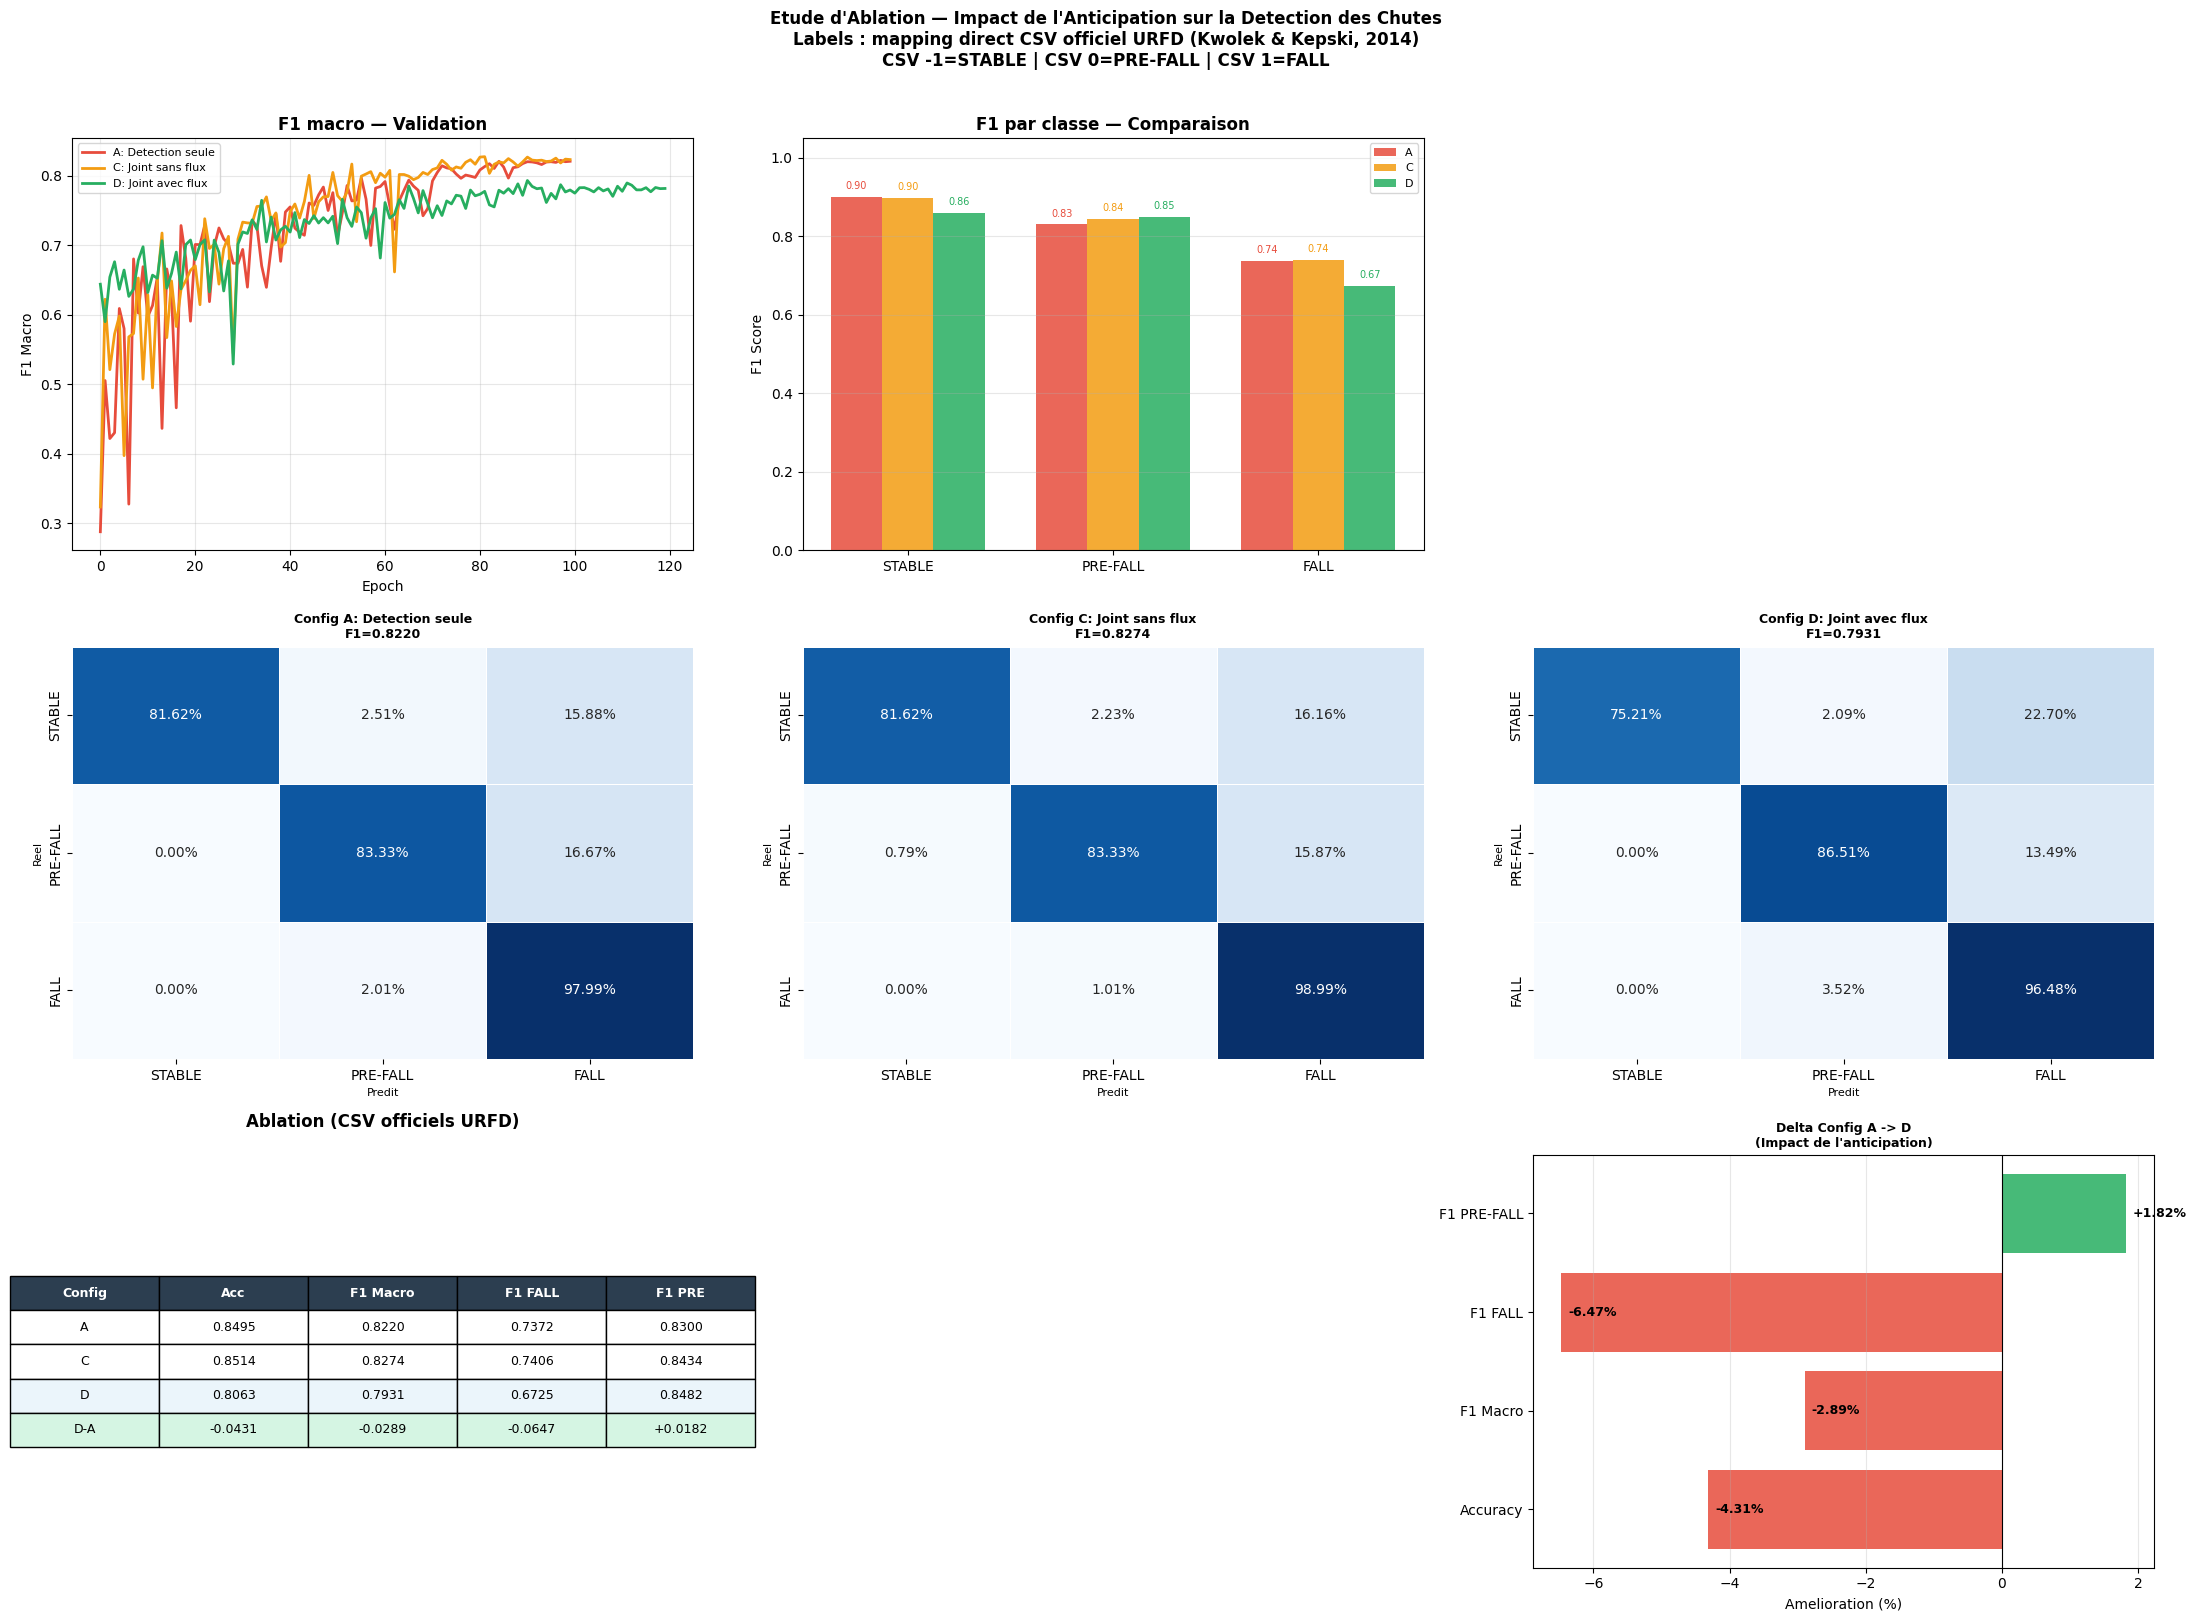

✅ Figure sauvegardee : /content/ablation_results.png


In [50]:
# ============================================================
# CELL 15 — Visualisations completes
# ============================================================
CLASS_NAMES = ['STABLE', 'PRE-FALL', 'FALL']
COLORS      = {'A': '#E74C3C', 'C': '#F39C12', 'D': '#27AE60'}

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('white')

# ── 1. Courbes F1 macro ──────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
for hist, tag, lbl in [(history_A, 'A', 'A: Detection seule'),
                        (history_C, 'C', 'C: Joint sans flux'),
                        (history_D, 'D', 'D: Joint avec flux')]:
    ax1.plot([h['val_f1'] for h in hist], color=COLORS[tag], lw=2, label=lbl)
ax1.set_title('F1 macro — Validation', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('F1 Macro')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── 2. F1 par classe ─────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)

def get_f1_per_class(ckpt, model, loader):
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            _, lD = model(xb.to(DEVICE))
            preds.extend(lD.argmax(1).cpu().numpy())
            true.extend(yb.numpy())
    return f1_score(true, preds, average=None, zero_division=0)

f1_A = get_f1_per_class(ckpt_A, model_A, val_loader_urfd)
f1_C = get_f1_per_class(ckpt_C, model_C, val_loader_urfd)
f1_D = get_f1_per_class(ckpt_D, model_D, val_loader_urfd)

x, w = np.arange(3), 0.25
ax2.bar(x - w, f1_A[:3], w, label='A', color=COLORS['A'], alpha=0.85)
ax2.bar(x,     f1_C[:3], w, label='C', color=COLORS['C'], alpha=0.85)
ax2.bar(x + w, f1_D[:3], w, label='D', color=COLORS['D'], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 par classe — Comparaison', fontweight='bold')
ax2.legend(fontsize=8); ax2.set_ylim(0, 1.05); ax2.grid(axis='y', alpha=0.3)
for i, (a, c, d) in enumerate(zip(f1_A[:3], f1_C[:3], f1_D[:3])):
    ax2.text(i - w, a + 0.02, f'{a:.2f}', ha='center', fontsize=7, color=COLORS['A'])
    ax2.text(i,     c + 0.02, f'{c:.2f}', ha='center', fontsize=7, color=COLORS['C'])
    ax2.text(i + w, d + 0.02, f'{d:.2f}', ha='center', fontsize=7, color=COLORS['D'])

# ── 3-5. Matrices de confusion ───────────────────────────────
def get_cm(ckpt, model, loader):
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            _, lD = model(xb.to(DEVICE))
            preds.extend(lD.argmax(1).cpu().numpy())
            true.extend(yb.numpy())
    return confusion_matrix(true, preds), true, preds

for idx, (name, ckpt, mdl) in enumerate([
    ('A: Detection seule', ckpt_A, model_A),
    ('C: Joint sans flux', ckpt_C, model_C),
    ('D: Joint avec flux', ckpt_D, model_D)
]):
    ax_cm = fig.add_subplot(3, 3, 4 + idx)
    cm, true, preds = get_cm(ckpt, mdl, val_loader_urfd)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax_cm, cbar=False, linewidths=0.5)
    f1_mac = f1_score(true, preds, average='macro', zero_division=0)
    ax_cm.set_title(f'Config {name}\nF1={f1_mac:.4f}', fontweight='bold', fontsize=9)
    ax_cm.set_xlabel('Predit', fontsize=8); ax_cm.set_ylabel('Reel', fontsize=8)

# ── 7. Tableau ───────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
ax7.axis('off')
td = [
    ['Config', 'Acc', 'F1 Macro', 'F1 FALL', 'F1 PRE'],
    ['A', f"{ckpt_A['val_acc']:.4f}", f"{ckpt_A['val_f1']:.4f}",
     f"{ckpt_A['f1_fall']:.4f}", f"{ckpt_A['f1_pre']:.4f}"],
    ['C', f"{ckpt_C['val_acc']:.4f}", f"{ckpt_C['val_f1']:.4f}",
     f"{ckpt_C['f1_fall']:.4f}", f"{ckpt_C['f1_pre']:.4f}"],
    ['D', f"{ckpt_D['val_acc']:.4f}", f"{ckpt_D['val_f1']:.4f}",
     f"{ckpt_D['f1_fall']:.4f}", f"{ckpt_D['f1_pre']:.4f}"],
    ['D-A', f'{delta_acc:+.4f}', f'{delta_f1:+.4f}',
     f'{delta_fall:+.4f}', f'{delta_pre:+.4f}'],
]
tbl = ax7.table(cellText=td[1:], colLabels=td[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.8)
for j in range(5):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[4, j].set_facecolor('#D5F5E3')
    tbl[3, j].set_facecolor('#EBF5FB')
ax7.set_title('Ablation (CSV officiels URFD)', fontweight='bold', pad=20)

# ── 9. Delta A->D ────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
metrics   = ['Accuracy', 'F1 Macro', 'F1 FALL', 'F1 PRE-FALL']
deltas_ad = [delta_acc, delta_f1, delta_fall, delta_pre]
clrs      = ['#27AE60' if d > 0 else '#E74C3C' for d in deltas_ad]
bars      = ax9.barh(metrics, [d * 100 for d in deltas_ad], color=clrs, alpha=0.85)
ax9.axvline(0, color='black', linewidth=0.8)
ax9.set_xlabel('Amelioration (%)')
ax9.set_title('Delta Config A -> D\n(Impact de l\'anticipation)',
               fontweight='bold', fontsize=9)
for bar, d in zip(bars, deltas_ad):
    ax9.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{d*100:+.2f}%', va='center', fontsize=9, fontweight='bold')
ax9.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Etude d\'Ablation — Impact de l\'Anticipation sur la Detection des Chutes\n'
    'Labels : mapping direct CSV officiel URFD (Kwolek & Kepski, 2014)\n'
    'CSV -1=STABLE | CSV 0=PRE-FALL | CSV 1=FALL',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('/content/ablation_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardee : /content/ablation_results.png')

  ANALYSE DU LEAD TIME D'ANTICIPATION
  Reference : CSV officiel URFD, label 0 = debut PRE-FALL

  Sequences de chute         : 32
  Alertes emises avant chute : 28
  Taux d'alerte precoce      : 87.5%

  Lead time (@ 30 FPS) :
    Moyenne  : 9.2 frames = 0.307 s
    Mediane  : 4.0 frames = 0.133 s
    Min      : 1 frames = 0.033 s
    Max      : 65 frames = 2.167 s


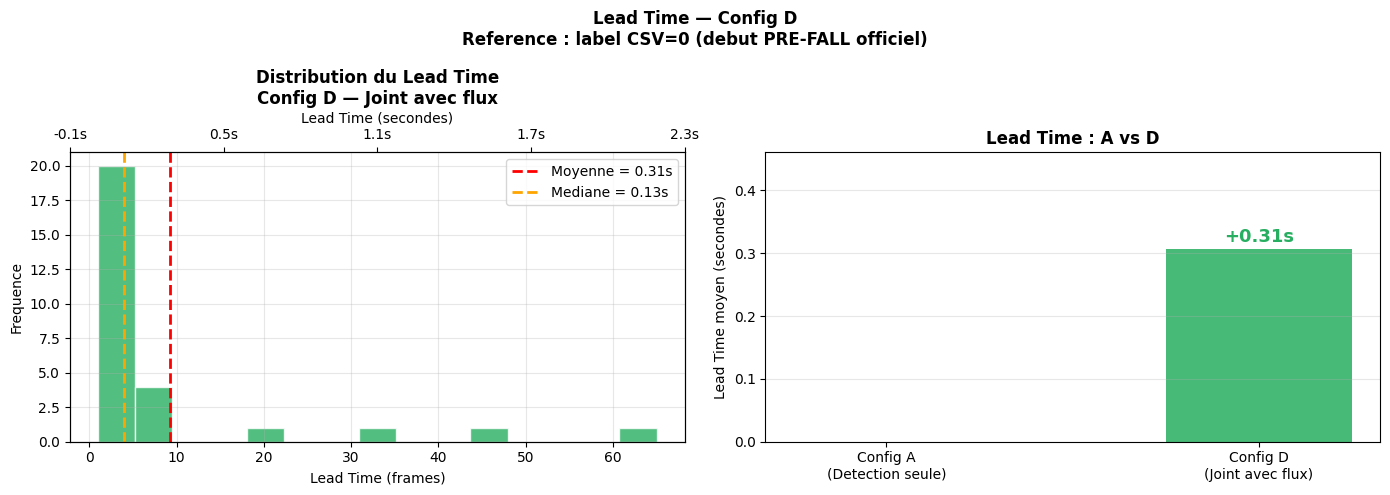

✅ Lead time sauvegarde


In [51]:
# ============================================================
# CELL 16 — Analyse Lead Time
# ============================================================
# Le lead time est mesure par rapport au premier frame avec
# label CSV=0 (PRE-FALL officiel), pas une approximation.
# ─────────────────────────────────────────────────────────────
print('  ANALYSE DU LEAD TIME D\'ANTICIPATION')
print('  Reference : CSV officiel URFD, label 0 = debut PRE-FALL')
print('=' * 55)

ckpt_D_loaded = torch.load('/content/model_D.pth',
                            map_location=DEVICE, weights_only=False)
model_D.load_state_dict(ckpt_D_loaded['model_state'])
model_D.eval()

lead_times = []
alerted    = 0
total_fall = 0

with torch.no_grad():
    for sample in labeled_data:
        kp     = sample['keypoints']
        labels = sample['labels']
        T      = len(kp)

        # Seulement les sequences avec FALL (label=2, CSV=1)
        if 2 not in labels:
            continue
        total_fall += 1
        if T < WINDOW_SIZE_URFD + 1:
            continue

        feats = extract_features_skeleton(kp)
        windows, win_end = [], []
        for start in range(0, T - WINDOW_SIZE_URFD):
            end = start + WINDOW_SIZE_URFD
            windows.append(feats[start:end])
            win_end.append(end - 1)

        xb = torch.tensor(np.array(windows), dtype=torch.float32).to(DEVICE)
        _, logits_D = model_D(xb)
        preds = logits_D.argmax(dim=1).cpu().numpy()

        # 1er frame predit PRE-FALL par le modele
        first_pre_win    = next((i for i, p in enumerate(preds) if p == 1), None)
        # 1er frame PRE-FALL reel (CSV=0, label=1 dans notre mapping)
        first_pre_real   = next((i for i, l in enumerate(labels) if l == 1), None)

        if first_pre_win is not None and first_pre_real is not None:
            alert_frame = win_end[first_pre_win]
            lead_frames = first_pre_real - alert_frame
            if lead_frames > 0:
                lead_times.append(lead_frames)
                alerted += 1

print(f'\n  Sequences de chute         : {total_fall}')
print(f'  Alertes emises avant chute : {alerted}')
print(f'  Taux d\'alerte precoce      : {alerted/max(total_fall,1)*100:.1f}%')

if lead_times:
    arr = np.array(lead_times)
    print(f'\n  Lead time (@ {FPS_URFD} FPS) :')
    print(f'    Moyenne  : {arr.mean():.1f} frames = {arr.mean()/FPS_URFD:.3f} s')
    print(f'    Mediane  : {np.median(arr):.1f} frames = {np.median(arr)/FPS_URFD:.3f} s')
    print(f'    Min      : {arr.min()} frames = {arr.min()/FPS_URFD:.3f} s')
    print(f'    Max      : {arr.max()} frames = {arr.max()/FPS_URFD:.3f} s')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(arr, bins=15, color='#27AE60', alpha=0.8, edgecolor='white')
    axes[0].axvline(arr.mean(),     color='red',    ls='--', lw=2,
                     label=f'Moyenne = {arr.mean()/FPS_URFD:.2f}s')
    axes[0].axvline(np.median(arr), color='orange', ls='--', lw=2,
                     label=f'Mediane = {np.median(arr)/FPS_URFD:.2f}s')
    axes[0].set_xlabel('Lead Time (frames)')
    axes[0].set_ylabel('Frequence')
    axes[0].set_title('Distribution du Lead Time\nConfig D — Joint avec flux',
                       fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    ax2t = axes[0].twiny()
    ticks = np.linspace(*axes[0].get_xlim(), 5)
    ax2t.set_xlim(axes[0].get_xlim())
    ax2t.set_xticks(ticks)
    ax2t.set_xticklabels([f'{v/FPS_URFD:.1f}s' for v in ticks])
    ax2t.set_xlabel('Lead Time (secondes)')

    axes[1].bar(['Config A\n(Detection seule)', 'Config D\n(Joint avec flux)'],
                 [0, arr.mean() / FPS_URFD],
                 color=[COLORS['A'], COLORS['D']], alpha=0.85, width=0.5)
    axes[1].set_ylabel('Lead Time moyen (secondes)')
    axes[1].set_title('Lead Time : A vs D', fontweight='bold')
    axes[1].text(1, arr.mean() / FPS_URFD + 0.01,
                  f'+{arr.mean()/FPS_URFD:.2f}s',
                  ha='center', fontweight='bold', fontsize=13, color=COLORS['D'])
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, arr.mean() / FPS_URFD * 1.5)

    plt.suptitle('Lead Time — Config D\nReference : label CSV=0 (debut PRE-FALL officiel)',
                  fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/lead_time_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('✅ Lead time sauvegarde')

In [52]:
# ============================================================
# CELL 17 — Rapport final + rapport de classification
# ============================================================
print('\n' + '=' * 62)
print('RAPPORT FINAL — THESE DE DOCTORAT')
print('=' * 62)

ckpt_D_loaded = torch.load('/content/model_D.pth',
                            map_location=DEVICE, weights_only=False)
model_D.load_state_dict(ckpt_D_loaded['model_state'])
model_D.eval()
all_preds_D, all_true_D = [], []
with torch.no_grad():
    for xb, yb in val_loader_urfd:
        _, lD = model_D(xb.to(DEVICE))
        all_preds_D.extend(lD.argmax(1).cpu().numpy())
        all_true_D.extend(yb.numpy())

print('\n Config D — Rapport de classification complet :')
print(classification_report(all_true_D, all_preds_D,
                             target_names=CLASS_NAMES, zero_division=0))

lead_mean_s = np.mean(lead_times) / FPS_URFD if lead_times else 0

print('\n' + '=' * 62)
print('SYNTHESE')
print('=' * 62)
print(f'''
LABELS : mapping direct CSV officiel URFD
  CSV -1 = STABLE   (0)
  CSV  0 = PRE-FALL (1)  <- en train de tomber
  CSV  1 = FALL     (2)  <- allongee sur le sol
  Aucune heuristique. Aucune approximation.

CONTRIBUTION 1 — Joint Learning (A -> D) :
  DeltaF1_macro = {delta_f1*100:+.2f}%
  DeltaF1_FALL  = {delta_fall*100:+.2f}%
  H1 : {"VALIDEE" if h1 else "NON VALIDEE"}

CONTRIBUTION 2 — Flux explicite e_A (C -> D) :
  DeltaF1_FALL  = {d_dc*100:+.2f}%
  H2 : {"VALIDEE" if h2 else "NON VALIDEE"}

CONTRIBUTION 3 — Lead Time :
  {alerted}/{total_fall} chutes alertees avant impact
  Lead time moyen : {lead_mean_s:.3f}s

ARCHITECTURE :
  CASIA-B SimCC -> LSTMAnticipator (pre-entrainement)
        |_ transfer weights
  URFD (CSV labels) -> JointAnticipateDetectModel
       SharedEncoder (DGNN + BiGRU + Attention)
           |-- AnticipationHead -> e_A (STABLE/PRE-FALL)
           |-- DetectionHead([z||e_A]) -> STABLE/PRE-FALL/FALL
       L_total = 0.4*L_A + 0.6*L_D
''')

from google.colab import files
for fname in ['/content/ablation_results.png',
              '/content/lead_time_analysis.png',
              '/content/urfd_labels_verification.png']:
    try:
        files.download(fname)
    except Exception:
        print(f'  {fname} — telechargement manuel requis')


RAPPORT FINAL — THESE DE DOCTORAT

 Config D — Rapport de classification complet :
              precision    recall  f1-score   support

      STABLE       1.00      0.75      0.86       718
    PRE-FALL       0.83      0.87      0.85       126
        FALL       0.52      0.96      0.67       199

    accuracy                           0.81      1043
   macro avg       0.78      0.86      0.79      1043
weighted avg       0.89      0.81      0.82      1043


SYNTHESE

LABELS : mapping direct CSV officiel URFD
  CSV -1 = STABLE   (0)
  CSV  0 = PRE-FALL (1)  <- en train de tomber
  CSV  1 = FALL     (2)  <- allongee sur le sol
  Aucune heuristique. Aucune approximation.

CONTRIBUTION 1 — Joint Learning (A -> D) :
  DeltaF1_macro = -2.89%
  DeltaF1_FALL  = -6.47%
  H1 : NON VALIDEE

CONTRIBUTION 2 — Flux explicite e_A (C -> D) :
  DeltaF1_FALL  = -6.81%
  H2 : NON VALIDEE

CONTRIBUTION 3 — Lead Time :
  28/32 chutes alertees avant impact
  Lead time moyen : 0.307s

ARCHITECTURE :
  CA

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>